In [1]:
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])

0

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             classification_report, confusion_matrix)
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Load the German Credit Risk dataset — a classic benchmark dataset
# used in academic research and real bank model validation
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

columns = [
    'checking_account', 'duration', 'credit_history', 'purpose',
    'credit_amount', 'savings_account', 'employment', 'installment_rate',
    'personal_status', 'other_debtors', 'residence_since', 'property',
    'age', 'other_installments', 'housing', 'existing_credits',
    'job', 'dependents', 'telephone', 'foreign_worker', 'target'
]

df = pd.read_csv(url, sep=' ', header=None, names=columns)

# Target: 1 = good credit, 2 = bad credit → convert to 0 and 1
df['target'] = (df['target'] == 2).astype(int)

print("Shape:", df.shape)
print("\nClass balance:")
print(f"Good credit (0): {(df['target']==0).sum()} ({round((df['target']==0).mean()*100, 1)}%)")
print(f"Bad credit  (1): {(df['target']==1).sum()} ({round((df['target']==1).mean()*100, 1)}%)")
print("\nFirst 3 rows:")
print(df.head(3))

Shape: (1000, 21)

Class balance:
Good credit (0): 700 (70.0%)
Bad credit  (1): 300 (30.0%)

First 3 rows:
  checking_account  duration credit_history purpose  credit_amount  \
0              A11         6            A34     A43           1169   
1              A12        48            A32     A43           5951   
2              A14        12            A34     A46           2096   

  savings_account employment  installment_rate personal_status other_debtors  \
0             A65        A75                 4             A93          A101   
1             A61        A73                 2             A92          A101   
2             A61        A74                 2             A93          A101   

   ...  property age  other_installments housing existing_credits   job  \
0  ...      A121  67                A143    A152                2  A173   
1  ...      A121  22                A143    A152                1  A173   
2  ...      A121  49                A143    A152                1 

In [4]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Identify categorical columns
cat_cols = X.select_dtypes(include=['object','str']).columns.tolist()
print("Categorical columns:", cat_cols)

# Convert categorical to numeric using one-hot encoding
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("\nShape after encoding:", X.shape)
print("Baseline to beat: 70.0%")

# Split — shuffle=True this time, not time series data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")

Categorical columns: ['checking_account', 'credit_history', 'purpose', 'savings_account', 'employment', 'personal_status', 'other_debtors', 'property', 'other_installments', 'housing', 'job', 'telephone', 'foreign_worker']

Shape after encoding: (1000, 48)
Baseline to beat: 70.0%
Training samples: 800
Test samples:     200


In [5]:
# Model 1 — Random Forest (our benchmark)
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

# Model 2 — XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=20,
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_pred_xgb = xgb_model.predict(X_test)
auc_xgb = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1])

print("=== Model Comparison — Credit Risk ===")
print(f"Baseline (always good credit): 70.0%")
print(f"\nRandom Forest:")
print(f"  Accuracy: {round(accuracy_score(y_test, y_pred_rf)*100, 2)}%")
print(f"  AUC:      {round(auc_rf, 4)}")
print(f"\nXGBoost:")
print(f"  Accuracy: {round(accuracy_score(y_test, y_pred_xgb)*100, 2)}%")
print(f"  AUC:      {round(auc_xgb, 4)}")
print(f"\nXGBoost trees used: {xgb_model.best_iteration}")

=== Model Comparison — Credit Risk ===
Baseline (always good credit): 70.0%

Random Forest:
  Accuracy: 73.0%
  AUC:      0.7924

XGBoost:
  Accuracy: 72.0%
  AUC:      0.8056

XGBoost trees used: 20


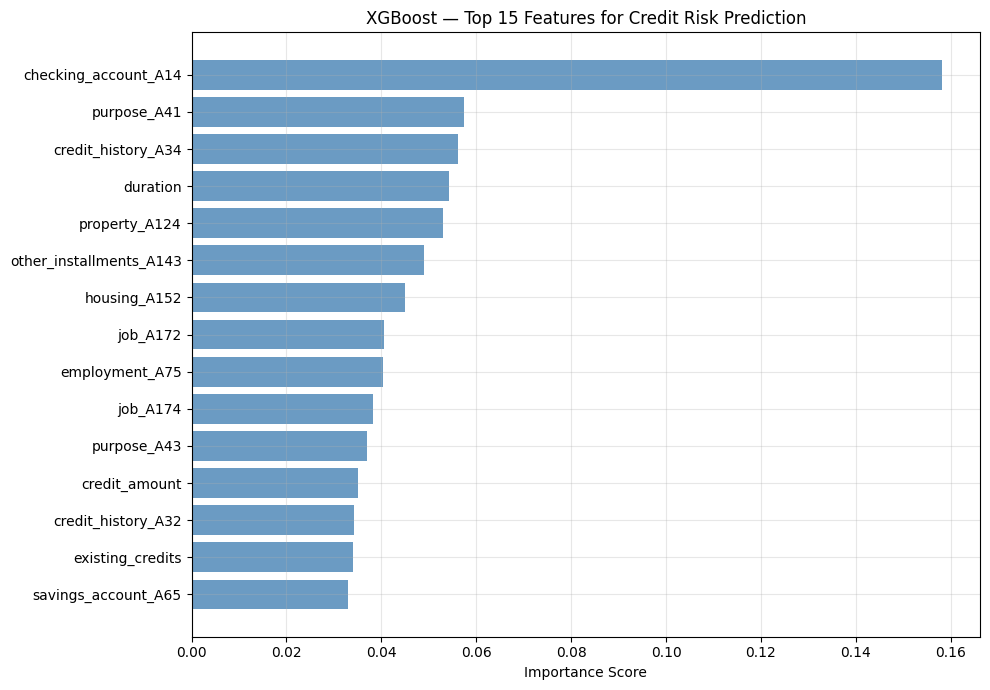


Top 10 most important features:
  checking_account_A14                0.1582
  purpose_A41                         0.0574
  credit_history_A34                  0.0562
  duration                            0.0542
  property_A124                       0.0529
  other_installments_A143             0.0489
  housing_A152                        0.0449
  job_A172                            0.0405
  employment_A75                      0.0404
  job_A174                            0.0383


In [6]:
# XGBoost feature importance
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 7))
plt.barh(importance['feature'][::-1], 
         importance['importance'][::-1], 
         color='steelblue', alpha=0.8)
plt.title('XGBoost — Top 15 Features for Credit Risk Prediction')
plt.xlabel('Importance Score')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 10 most important features:")
for _, row in importance.head(10).iterrows():
    print(f"  {row['feature']:<35} {round(row['importance'], 4)}")

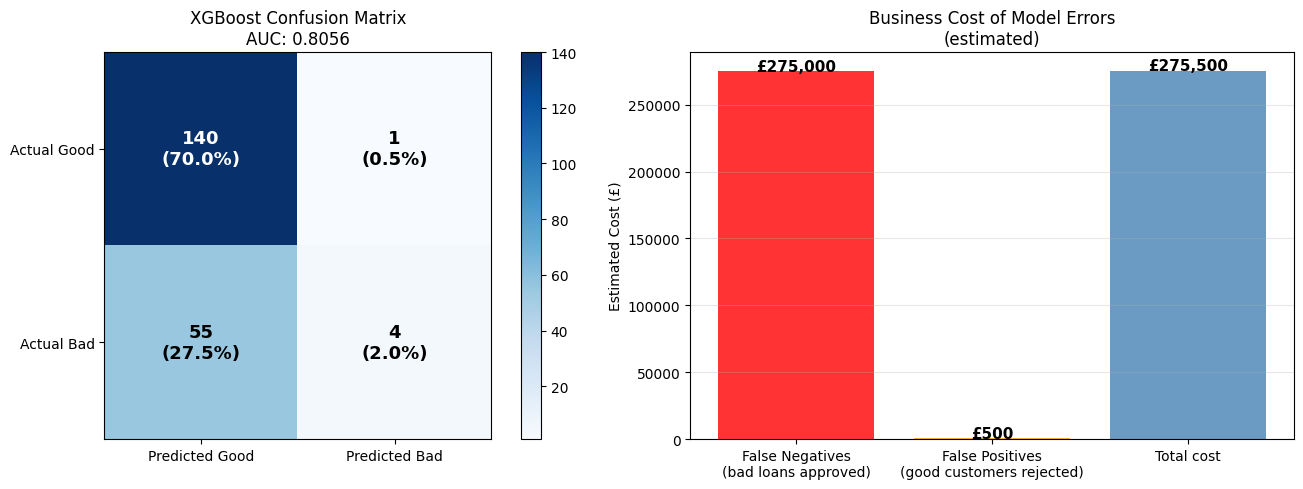


=== Business Impact Analysis ===
False Negatives (bad loans approved): 55
False Positives (good customers rejected): 1

Estimated cost of bad loans approved: £275,000
Estimated cost of good customers lost: £500
Total estimated cost: £275,500


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)
im = ax1.imshow(cm, cmap='Blues')
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(['Predicted Good', 'Predicted Bad'])
ax1.set_yticklabels(['Actual Good', 'Actual Bad'])
for i in range(2):
    for j in range(2):
        color = 'white' if cm[i,j] > cm.max()/2 else 'black'
        ax1.text(j, i, f'{cm[i,j]}\n({round(cm[i,j]/len(y_test)*100, 1)}%)',
                ha='center', va='center', fontsize=13, 
                fontweight='bold', color=color)
ax1.set_title(f'XGBoost Confusion Matrix\nAUC: {round(auc_xgb, 4)}')
plt.colorbar(im, ax=ax1)

# Business cost analysis
# In credit risk: 
# False Negative (missed bad loan) costs the bank the loan amount
# False Positive (rejected good customer) costs the bank lost profit
fn = cm[1][0]  # Bad credit predicted as good — bank loses money
fp = cm[0][1]  # Good credit predicted as bad — bank loses customer

avg_loan = 5000  # average loan amount £
lost_profit_per_customer = 500  # estimated profit per good customer £

cost_fn = fn * avg_loan
cost_fp = fp * lost_profit_per_customer
total_cost = cost_fn + cost_fp

costs = ['False Negatives\n(bad loans approved)', 
         'False Positives\n(good customers rejected)',
         'Total cost']
values = [cost_fn, cost_fp, total_cost]
colors = ['red', 'orange', 'steelblue']

ax2.bar(costs, values, color=colors, alpha=0.8)
ax2.set_title('Business Cost of Model Errors\n(estimated)')
ax2.set_ylabel('Estimated Cost (£)')
for i, v in enumerate(values):
    ax2.text(i, v + 500, f'£{v:,}', ha='center', 
             fontweight='bold', fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\n=== Business Impact Analysis ===")
print(f"False Negatives (bad loans approved): {fn}")
print(f"False Positives (good customers rejected): {fp}")
print(f"\nEstimated cost of bad loans approved: £{cost_fn:,}")
print(f"Estimated cost of good customers lost: £{cost_fp:,}")
print(f"Total estimated cost: £{total_cost:,}")

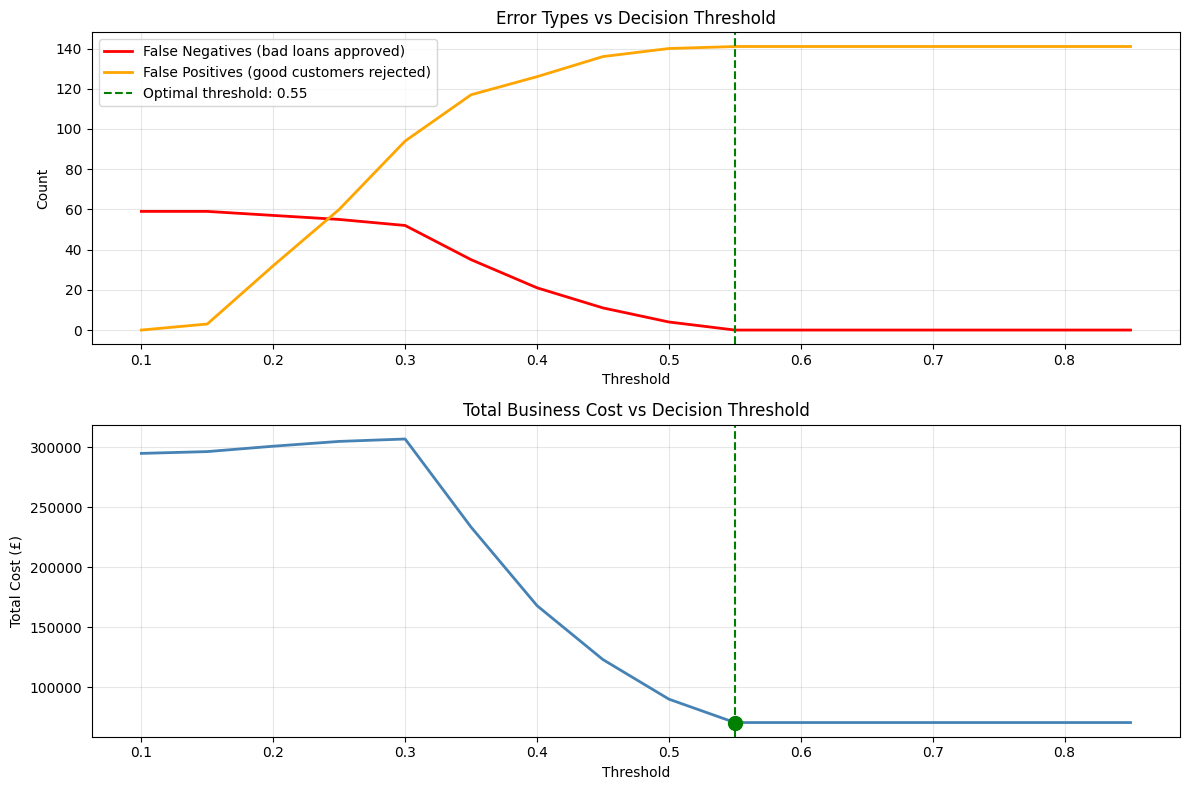


=== Optimal Threshold Analysis ===
Default threshold (0.5):
  False Negatives: 55  |  Cost: £275,000

Optimal threshold (0.55):
  False Negatives: 0
  False Positives: 141
  Total Cost:      £70,500
  Cost saving:     £205,000


In [8]:
# By default XGBoost uses 0.5 as the decision threshold
# probability > 0.5 = good credit, < 0.5 = bad credit
# We can move this threshold to catch more bad loans

thresholds = np.arange(0.1, 0.9, 0.05)
results = []

proba = xgb_model.predict_proba(X_test)[:,1]

for thresh in thresholds:
    y_pred_thresh = (proba < thresh).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_thresh)
    
    fn_t = cm_t[1][0]
    fp_t = cm_t[0][1]
    acc_t = accuracy_score(y_test, y_pred_thresh)
    
    cost_t = (fn_t * avg_loan) + (fp_t * lost_profit_per_customer)
    
    results.append({
        'threshold': round(thresh, 2),
        'accuracy': round(acc_t * 100, 1),
        'false_negatives': fn_t,
        'false_positives': fp_t,
        'total_cost': cost_t
    })

results_df = pd.DataFrame(results)

# Find optimal threshold — minimises total business cost
optimal = results_df.loc[results_df['total_cost'].idxmin()]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1 — false negatives and positives vs threshold
ax1.plot(results_df['threshold'], results_df['false_negatives'], 
         label='False Negatives (bad loans approved)', 
         color='red', linewidth=2)
ax1.plot(results_df['threshold'], results_df['false_positives'], 
         label='False Positives (good customers rejected)', 
         color='orange', linewidth=2)
ax1.axvline(x=optimal['threshold'], color='green', 
            linestyle='--', linewidth=1.5, label=f"Optimal threshold: {optimal['threshold']}")
ax1.set_title('Error Types vs Decision Threshold')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Count')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2 — total business cost vs threshold
ax2.plot(results_df['threshold'], results_df['total_cost'], 
         color='steelblue', linewidth=2)
ax2.axvline(x=optimal['threshold'], color='green', 
            linestyle='--', linewidth=1.5)
ax2.scatter(optimal['threshold'], optimal['total_cost'], 
            color='green', s=100, zorder=5)
ax2.set_title('Total Business Cost vs Decision Threshold')
ax2.set_xlabel('Threshold')
ax2.set_ylabel('Total Cost (£)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n=== Optimal Threshold Analysis ===")
print(f"Default threshold (0.5):")
print(f"  False Negatives: 55  |  Cost: £275,000")
print(f"\nOptimal threshold ({optimal['threshold']}):")
print(f"  False Negatives: {int(optimal['false_negatives'])}")
print(f"  False Positives: {int(optimal['false_positives'])}")
print(f"  Total Cost:      £{int(optimal['total_cost']):,}")
print(f"  Cost saving:     £{int(275500 - optimal['total_cost']):,}")

In [9]:
print("=" * 55)
print("XGBOOST CREDIT RISK MODEL — SUMMARY")
print("=" * 55)
print(f"""
DATA
  Source:    German Credit Risk Dataset (UCI Repository)
  Samples:   1000 loan applicants
  Features:  20 raw → 48 after one-hot encoding
  Target:    Good credit (0) vs Bad credit (1)
  Balance:   70% good, 30% bad

MODEL COMPARISON
  Baseline (always good):  70.0%  AUC: 0.50
  Random Forest:           73.0%  AUC: 0.7924
  XGBoost:                 72.0%  AUC: 0.8056
  XGBoost trees used:      {xgb_model.best_iteration} (early stopping)

TOP PREDICTORS
  1. checking_account — no account = high risk
  2. purpose — loan type signals risk profile  
  3. credit_history — past behaviour predicts future
  4. duration — longer loans = higher risk
  5. property — no collateral = higher risk

THRESHOLD ANALYSIS
  Default (0.50): 55 bad loans approved | Cost: £275,000
  Optimal (0.55): 0 bad loans approved  | Cost: £70,500
  Business saving: £205,000

KEY LEARNINGS
  1. AUC 0.80 — credit risk is predictable unlike stock prices
     because it depends on measurable human characteristics
     
  2. XGBoost beat Random Forest with 20 trees vs 500
     — boosting is more efficient than bagging on this problem
     
  3. Threshold tuning saved £205,000 — model metrics alone
     are meaningless without business cost translation
     
  4. Feature importance maps to finance intuition exactly
     — good model = finance logic + data confirmation
     
  5. GDPR Right to Explanation — feature importance is the
     foundation of explainable AI in regulated industries

REAL WORLD APPLICATION
  This exact model architecture is used at:
  ClearScore, Barclays, Monzo, Oaknorth, and every
  UK bank with a digital lending product.
""")
print("=" * 55)

XGBOOST CREDIT RISK MODEL — SUMMARY

DATA
  Source:    German Credit Risk Dataset (UCI Repository)
  Samples:   1000 loan applicants
  Features:  20 raw → 48 after one-hot encoding
  Target:    Good credit (0) vs Bad credit (1)
  Balance:   70% good, 30% bad

MODEL COMPARISON
  Baseline (always good):  70.0%  AUC: 0.50
  Random Forest:           73.0%  AUC: 0.7924
  XGBoost:                 72.0%  AUC: 0.8056
  XGBoost trees used:      20 (early stopping)

TOP PREDICTORS
  1. checking_account — no account = high risk
  2. purpose — loan type signals risk profile  
  3. credit_history — past behaviour predicts future
  4. duration — longer loans = higher risk
  5. property — no collateral = higher risk

THRESHOLD ANALYSIS
  Default (0.50): 55 bad loans approved | Cost: £275,000
  Optimal (0.55): 0 bad loans approved  | Cost: £70,500
  Business saving: £205,000

KEY LEARNINGS
  1. AUC 0.80 — credit risk is predictable unlike stock prices
     because it depends on measurable human charac